# NeRF

**To run NeRF, first run the COLMAP pipeline to get the poses and focal**

*Note:* This seemed to be very unstable, that clearly reconstructs sometimes and sometimes does not, even using the same data and code.

## Load Data

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
(102, 150, 150, 3) (102, 4, 4) 3276.8159026144594 150 150
Using device: cuda
Pose example:
 [[-0.9837933  -0.08766475  0.15641484 -0.64229643]
 [-0.01688573  0.9137528   0.40591958 -0.8966648 ]
 [-0.17850934  0.3966998  -0.9004242   3.7480085 ]
 [ 0.          0.          0.          1.        ]]


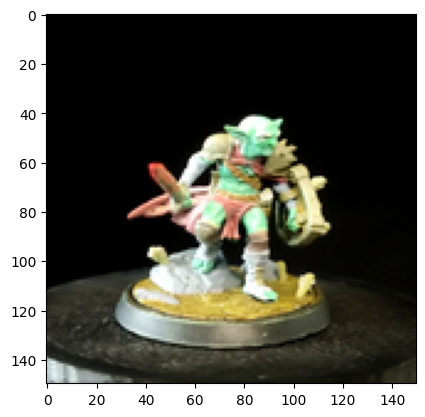

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../utils")
from colmap import load_nerf_data_from_colmap

train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/1",
    images_dir = "../data/images",
    image_size = (150, 150), # optional resize
)

H, W = train_images.shape[1:3]
print(train_images.shape, train_poses.shape, focal, H, W)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Pose example:\n", train_poses[0])
plt.imshow(test_images[0])
plt.show()
focal = np.array(focal)
testimg = torch.from_numpy(test_images[0]).float().to(device)
testpose = torch.from_numpy(test_poses[0]).float().to(device)

## Train Model

Using device: cuda


Training NeRF:   0%|          | 0/10000 [00:00<?, ?iter/s, loss=0.088579, psnr=9.65]

Iteration: 0, Loss: 0.088579, Time: 0.00 secs per iter


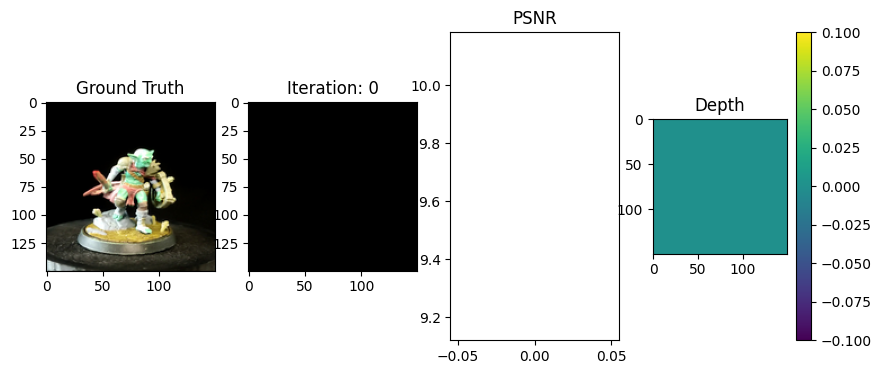

Training NeRF:  10%|█         | 1000/10000 [05:45<51:04,  2.94iter/s, loss=0.067721, psnr=11.16] 

Iteration: 1000, Loss: 0.067721, Time: 0.34 secs per iter


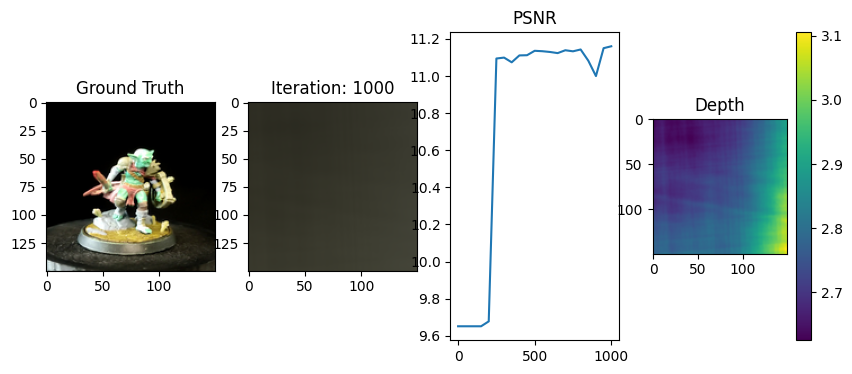

Training NeRF:  20%|██        | 2000/10000 [11:27<44:44,  2.98iter/s, loss=0.058244, psnr=11.10]  

Iteration: 2000, Loss: 0.058244, Time: 0.34 secs per iter


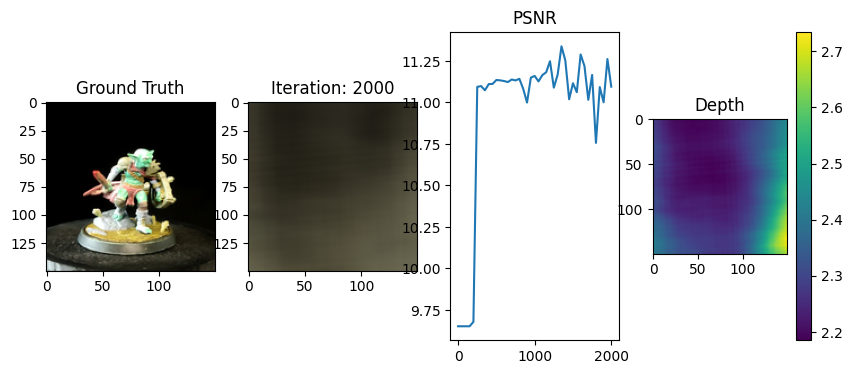

Training NeRF:  30%|███       | 3000/10000 [17:08<39:45,  2.93iter/s, loss=0.054200, psnr=11.13]  

Iteration: 3000, Loss: 0.054200, Time: 0.34 secs per iter


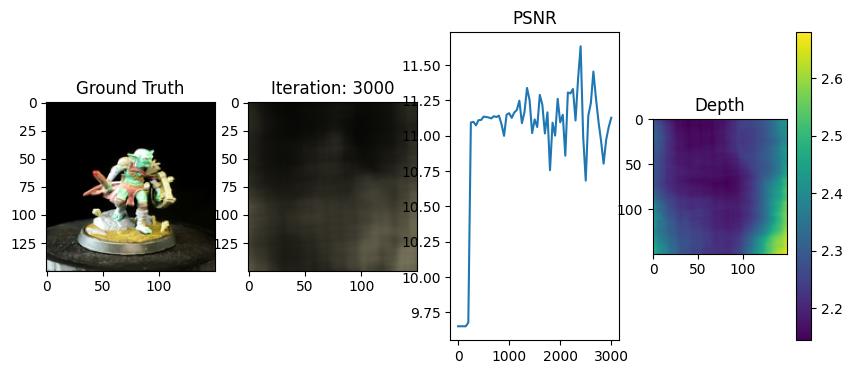

Training NeRF:  40%|████      | 4000/10000 [22:52<34:08,  2.93iter/s, loss=0.049155, psnr=10.21]

Iteration: 4000, Loss: 0.049155, Time: 0.34 secs per iter


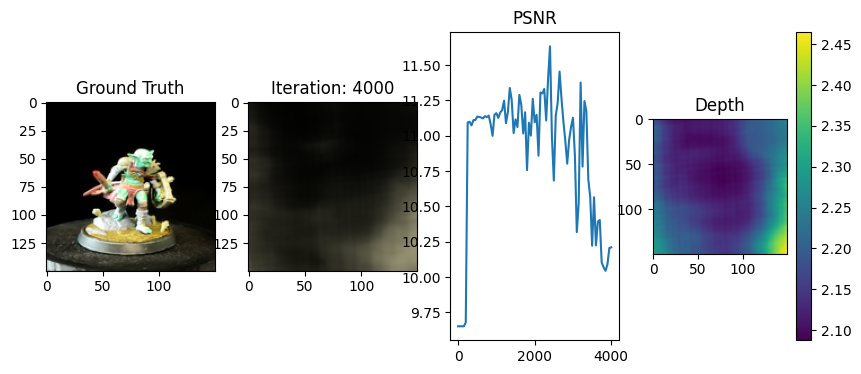

Training NeRF:  50%|█████     | 5000/10000 [28:39<28:29,  2.93iter/s, loss=0.031982, psnr=9.94] 

Iteration: 5000, Loss: 0.031982, Time: 0.35 secs per iter


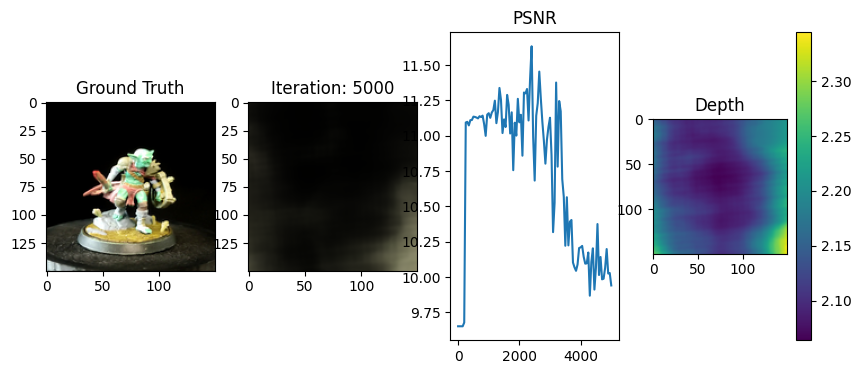

Training NeRF:  60%|██████    | 6000/10000 [34:25<22:33,  2.96iter/s, loss=0.027339, psnr=9.94] 

Iteration: 6000, Loss: 0.027339, Time: 0.35 secs per iter


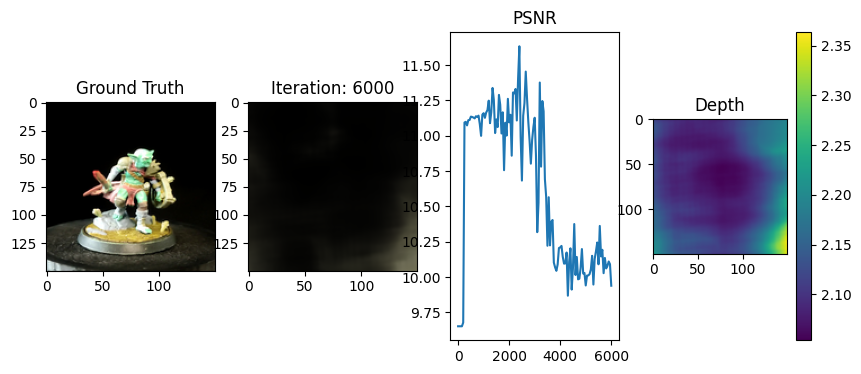

Training NeRF:  64%|██████▎   | 6365/10000 [36:30<20:50,  2.91iter/s, loss=0.022449, psnr=10.19]


KeyboardInterrupt: 

In [2]:
import sys
sys.path.append("../utils")
from nerf import train

n_iter = 10000
n_samples = 32
i_plot = 1000  # Interval for plotting
i_val = 50     # Interval for calculating val_loss

model = train(train_images, train_poses, H, W, focal, testpose, testimg, n_iter, n_samples, i_plot, i_val, device)

## Render Video

In [7]:
from nerf import get_rays, render_rays
from ipywidgets import interactive, widgets

# Transformation matrices in PyTorch
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi), torch.cos(phi), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0, torch.cos(th), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

# Pose function with spherical coordinates
def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = torch.matmul(rot_phi(torch.Tensor([phi / 180. * np.pi])), c2w)
    c2w = torch.matmul(rot_theta(torch.Tensor([theta / 180. * np.pi])), c2w)
    c2w = torch.tensor([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=torch.float32) @ c2w
    return c2w

# Function for rendering based on user input
def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])  # Get rays (this is a placeholder)
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device=device)  # Render rays
    rgb = rgb.reshape(H, W, 3).cpu().detach()
    img = torch.clamp(rgb, 0, 1).numpy()  # Clamp RGB values between 0 and 1 and convert to numpy

    plt.figure(2, figsize=(20, 6))
    plt.imshow(img)
    plt.show()

# Interactive slider setup for theta, phi, and radius
sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [9]:
from tqdm import tqdm

frames = []
frames_depth = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device = device)
    rgb = rgb.reshape(H, W, 3)
    frames.append((255*np.clip(rgb.cpu().detach().numpy(),0,1)).astype(np.uint8))
    frames_depth.append((255*np.clip(depth.cpu().detach().numpy(),0,1)).astype(np.uint8))

100%|██████████| 120/120 [01:04<00:00,  1.87it/s]


In [11]:
import imageio
imageio.mimwrite('../results/nerf/video.mp4', frames, fps=30, quality=7)
frames_depth_reshaped = [f.reshape(H, W) for f in frames_depth]
imageio.mimwrite('../results/nerf/video_depth.mp4', frames_depth_reshaped, fps=30, quality=7)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (150, 150) to (160, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (150, 150) to (160, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [12]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('../results/nerf/video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [13]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('../results/nerf/video_depth.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)